# **Representation Consistency and Identifiability in Modal-Based Stiffness Inversion**
---
## **1. Debug：二值分类的失败——信息的过渡压缩**
最初的尝试将损伤问题建模为二值分类（损伤/无损）。\
结果表明：

- 预测准确率很低80%左右
- **无法区分损伤的程度**
- **无法识别和刻画刚度的空间变化**

### **1.1 本质问题**
该分类模型将连续问题高度压缩为离散的标签，但最重要的是在这种高度压缩后，反演问题是典型的**多对一问题**：\
由于参数空间维度（高纬随机刚度场）显著高于模态观测空间维度（前5阶振型和模态，一共255个点），前向映射在数学上不具单射性。对于给定的模态响应，存在一个连续的刚度场子空间能够产生近似相同的观测结果。在大规模随机采样（8 万样本）条件下，该等响应子空间被充分填充，从而导致大量不同刚度分布在模态空间中发生重叠。\
在此情况下，学习模型面对“相同或极其相似输入对应不同物理机制”的样本结构，其最优解退化为条件期望或统计平均映射。由此产生空间模式模糊、局部损伤削弱以及分类边界塌缩等现象。这并非模型容量不足，而是观测信息维度受限所导致的结构性不可辨识问题。

### **1.2 结论**

所以此时可以断言，这是一次**表征层面的失败**。该分类的本质是一种过渡的压缩。

---
## **2. 反演KL系数**
### **2.1 回顾：前向建模中的 KL 子空间约束**
在随机刚度场生成阶段，我采用了 Karhunen–Loève 展开构造随机刚度比场，数学表达式如下：  $$ E_{l}(x, \omega) = \mu(x) + \sum_{k = 1}^{\infty} \sqrt{\lambda_k} \varphi_{k}(x) \xi_{k}(\omega) $$
其中： \
$\lambda_k$ 和 $\varphi_{k}(x)$ 是协方差函数的特征值和对应的正交特征向量函数。\
$\xi_{k}(\omega)$ 是一组相互独立的标准正态随机变量（均值为0，方差为1）。

#### **2.1.1 初始动机**
当时采用 KL 展开的主要动机是：

- 保证空间平滑性与物理合理性，即构建一个低维、可控且与有限元离散一致的随机刚度参数化方式
- 控制空间相关性（通过协方差核函数与相关长度）

#### **2.1.2 关键认识**
基于此，我现在才意识到，使用KL展开后，该前向问题本身**已经被限制在一个有限维的随机子空间中**，也就是说，本模型所生成的刚度场并不同于真实物理实验中的真实刚度场，其位于一个无限维的函数空间中，本模型的刚度场**位于一个K维的KL子空间中**。\
因此在理论上，若模态信息充分，反问题最多只需要恢复K个KL系数，在给出了一个理想的反演上限！

### **2.2 直接预测KL系数**
所以基于上述认识，现在让我们来重新定义一下这个反问题，我将其定义为：
$$模态特征 -> \{ \xi_{1}, \xi_{2}, \xi_{3}, ... ,\xi_{k} \}$$
此时，反问题的输出空间和前向建模空间一致！

### **2.3 实验结果**
训练神经网络直接预测 KL 系数后，得到如下现象：

- 平均 $R^2 ≈ 0.63$
- 主导模式最高 $R^2 ≈ 0.96$
- 某些样本出现极端负 $R^2$ (-300+) \
具体实验数据见下：
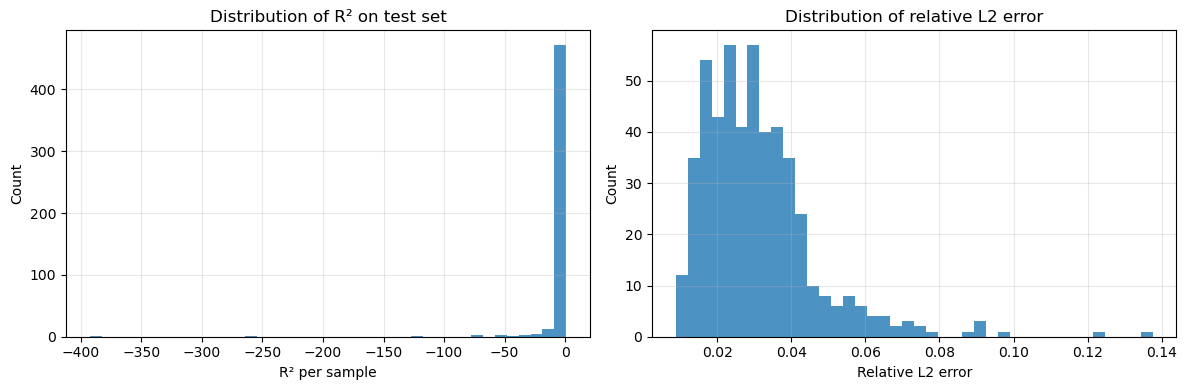
$R^{2}$的具体分布情况：
| 区间范围 | 个数 |
|------|------|
| [-1.0, -0.9) | 3 |
| [-0.9, -0.8) | 4 |
| [-0.8, -0.7) | 12 |
| [-0.7, -0.6) | 3 |
| [-0.6, -0.5) | 4 |
| [-0.5, -0.4) | 6 |
| [-0.4, -0.3) | 16 |
| [-0.3, -0.2) | 12 |
| [-0.2, -0.1) | 16 |
| [-0.1, 0.0) | 27 |
| [0.0, 0.1) | 29 |
| [0.1, 0.2) | 28 |
| [0.2, 0.3) | 37 |
| [0.3, 0.4) | 32 |
| [0.4, 0.5) | 29 |
| [0.5, 0.6) | 22 |
| [0.6, 0.7) | 16 |
| [0.7, 0.8) | 37 |
| [0.8, 0.9) | 49 |
| [0.9, 1.0) | 23 |
在[-1, 1]区间内，共有 405 个 （总共测试500个数据）
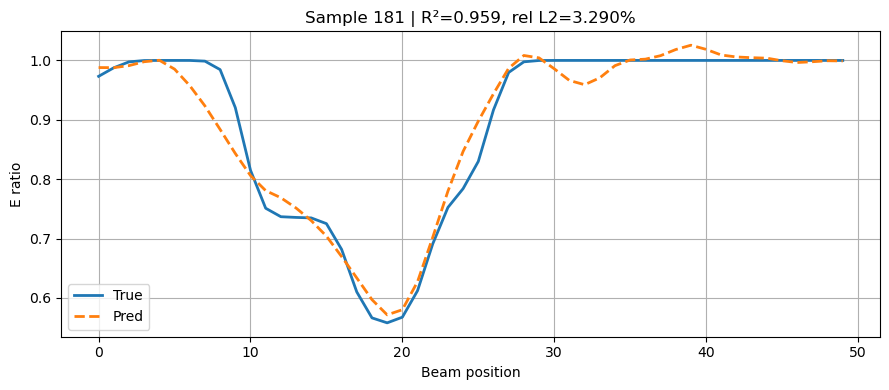
与二分类回归相比：

- 整体精度显著提升
- 但存在严重异常样本
这表明：**表征一致性确实减少了误差传播，但并未完全解决可辨识性问题**\
但是通过观察一个新的问题出现了：**在无损或接近无损样本中，预测误差被系统性放大**

### **2.4 无损样本中的系统性放大现象**
对异常样本进行检查后发现，这些样本大多都具有以下特征：

- 刚度扰动极小
- KL 系数真实值接近 0
- 模态频率与振型几乎不发生变化
在这种情况下，模型预测却出现非零偏差，甚至幅值明显大于真实扰动。见下图：
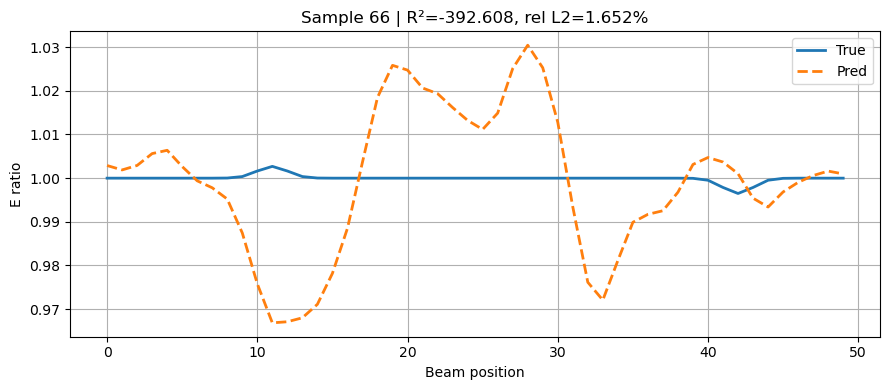
这表明了一个重要的物理倾向：**模型在低扰动区间存在“过度预测”倾向**

### **2.5 可能的物理解释**
对于接近无损状态：

- 模态对刚度变化的一阶敏感度趋近于 0
- 输入特征变化幅度极小
- 系统进入低信噪比区间

故在此区间内：**输入特征几乎无法区分真实零扰动与微小扰动**，于是便会产生**小扰动被夸大预测的现象**

### **2.6 当前阶段的保守结论**
目前可以确认的结论是：

- 表征一致性显著优于二分类回归
- 在接近无损状态下存在系统性预测放大

### **2.7 猜想与未来进一步工作**
基于当前观察，我觉得现在的问题不再是网络的参数问题或者输入输出和训练维数的不匹配问题，而是两个个更重要的问题**KL模式的可辨识程度问题**和**模态灵敏度问题**，所以下一步工作将集中于：**模态敏感度分析**和**可辨识维度估计**